In [ ]:
%%capture
!pip install pandas scikit-learn keras tensorflow
!pip install transformers torch
!pip install datasets


In [ ]:
import torch
print(torch.cuda.is_available())


True


Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/727 [00:00<?, ? examples/s]

Map:   0%|          | 0/81 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-6-ca0aa3e2bf38>:106: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.649000,0.609287,0.913580
2,0.508900,0.404341,0.901235
3,0.388700,0.359551,0.950617
4,0.313000,0.284414,0.962963
5,0.223900,0.219336,0.913580
6,0.184700,0.138006,0.950617
7,0.131700,0.066396,0.987654
8,0.028000,0.074718,0.987654


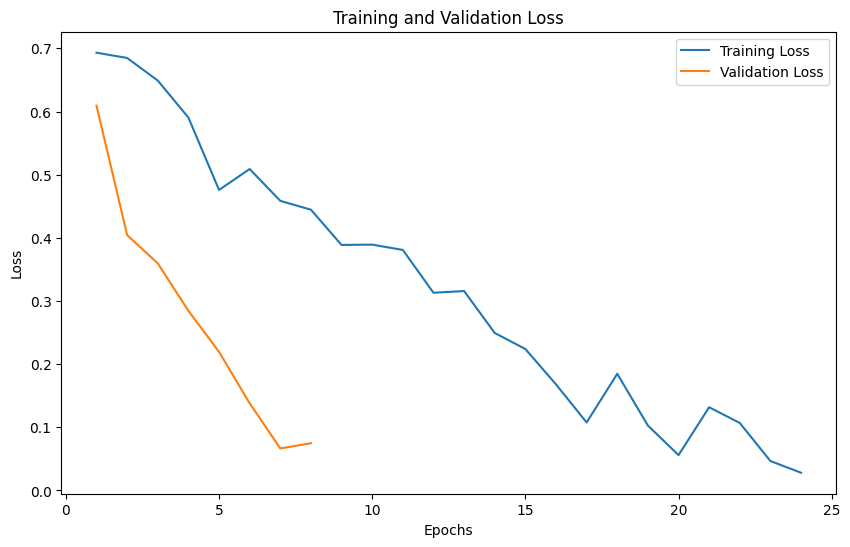

Model Performance on Test Set
              precision    recall  f1-score   support

          AI       0.87      0.81      0.84        48
       HUMAN       0.84      0.88      0.86        52

    accuracy                           0.85       100
   macro avg       0.85      0.85      0.85       100
weighted avg       0.85      0.85      0.85       100



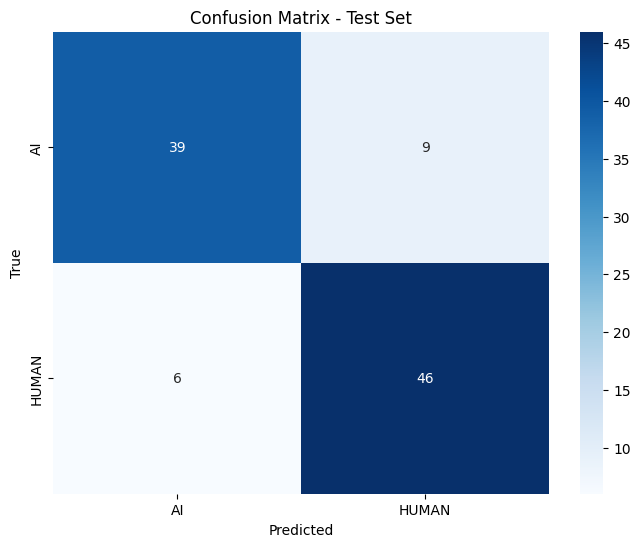

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
import torch
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns

#os.environ["WANDB_MODE"] = "disabled"

train_data = pd.read_csv("tam_train.csv")
test_data = pd.read_csv("tam_test.csv")

def preprocess_text(text):
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_data["DATA"] = train_data["DATA"].apply(preprocess_text)
test_data["DATA"] = test_data["DATA"].apply(preprocess_text)
train_data.dropna(subset=["DATA", "LABEL"], inplace=True)

label_encoder = LabelEncoder()
train_data["LABEL"] = label_encoder.fit_transform(train_data["LABEL"])

train_data, val_data = train_test_split(train_data, test_size=0.1, random_state=42, stratify=train_data["LABEL"])

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_train_features = tfidf_vectorizer.fit_transform(train_data["DATA"].values).toarray()
tfidf_val_features = tfidf_vectorizer.transform(val_data["DATA"].values).toarray()

sentences = [row.split() for row in train_data["DATA"]]
word2vec_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

def get_word2vec_features(data, model):
    features = []
    for sentence in data:
        words = sentence.split()
        word_vectors = [model.wv[word] for word in words if word in model.wv]
        if word_vectors:
            features.append(np.mean(word_vectors, axis=0))
        else:
            features.append(np.zeros(model.vector_size))
    return np.array(features)

word2vec_train_features = get_word2vec_features(train_data["DATA"], word2vec_model)
word2vec_val_features = get_word2vec_features(val_data["DATA"], word2vec_model)

train_data = train_data.rename(columns={"DATA": "text", "LABEL": "label"})
val_data = val_data.rename(columns={"DATA": "text", "LABEL": "label"})
test_data = test_data.rename(columns={"DATA": "text"})

train_dataset = Dataset.from_pandas(train_data)
val_dataset = Dataset.from_pandas(val_data)
test_dataset = Dataset.from_pandas(test_data)

model_name = "ai4bharat/indic-bert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_encoder.classes_))

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text", "ID"])
val_dataset = val_dataset.remove_columns(["text", "ID"])
test_dataset = test_dataset.remove_columns(["text", "ID"])
train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=15,
    save_total_limit=2,
    load_best_model_at_end=True,
    no_cuda=False
)

def compute_metrics(pred):
    labels = torch.tensor(pred.label_ids, device="cuda" if torch.cuda.is_available() else "cpu")
    preds = torch.tensor(pred.predictions, device=labels.device).argmax(dim=1)
    acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
    return {"accuracy": acc}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

trainer.train()

metrics = trainer.state.log_history
train_loss = [x['loss'] for x in metrics if 'loss' in x]
val_loss = [x['eval_loss'] for x in metrics if 'eval_loss' in x]
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs[:len(val_loss)], val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

predictions = trainer.predict(test_dataset)
test_data["LABEL_PRED"] = label_encoder.inverse_transform(predictions.predictions.argmax(axis=1))

test_data[["ID", "LABEL_PRED"]].to_csv('prediction.csv', index=False)

report = classification_report(test_data["LABEL"], test_data["LABEL_PRED"], target_names=label_encoder.classes_)
print('Model Performance on Test Set')
print(report)

conf_matrix_test = confusion_matrix(test_data['LABEL'], test_data["LABEL_PRED"])
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_test, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()